# MNIST + HDFS + Spark

The purpose of this notebook is to test whether HDFS + Spark can successfully supply data to PyTorch (simply to verify the integration).

In [24]:
import gzip
import time
import random
import numpy as np
import struct
import matplotlib.pyplot as plt
import torch
import torchvision
import pyspark

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("PySpark:", pyspark.__version__)

PyTorch: 2.14.1+cu130
Torchvision: 0.29.1+cu130
PySpark: 4.1.2


In [2]:
import sys
print(sys.executable)

import pyspark
print("PySpark:", pyspark.__version__)
print("PySpark location:", pyspark.__file__)

/home/hduser/.conda/envs/cnn/bin/python
PySpark: 4.1.2
PySpark location: /home/hduser/.conda/envs/cnn/lib/python3.11/site-packages/pyspark/__init__.py


In [4]:
from pyspark.sql import SparkSession

# create a Spark session for the Spark data pipeline
spark = SparkSession.builder \
    .appName("MNIST_Spark_Pipeline") \
    .master("local[*]") \
    .getOrCreate()

print("Spark version:", spark.version)
print("Master:", spark.sparkContext.master)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/10/03 08:30:24 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 4.1.2
Master: local[*]


In [5]:
hadoop_conf = spark.sparkContext._jsc.hadoopConfiguration()

print(hadoop_conf.get("fs.defaultFS"))

hdfs://localhost:9000


The original MNIST distribution is in the binary IDX/ubyte format, and the files are distributed compressed as .gz.

We've put these files to HDFS:
- -rw-r--r--   1 hduser supergroup    1648877 2026-10-01 19:13 /ca1/mnist_test/t10k-images-idx3-ubyte.gz
- -rw-r--r--   1 hduser supergroup       4542 2026-10-01 19:13 /ca1/mnist_test/t10k-labels-idx1-ubyte.gz
- -rw-r--r--   1 hduser supergroup    9912422 2026-10-01 19:13 /ca1/mnist_test/train-images-idx3-ubyte.gz
- -rw-r--r--   1 hduser supergroup      28881 2026-10-01 19:13 /ca1/mnist_test/train-labels-idx1-ubyte.gz

We first use Spark's binary-file reader to establish that Spark can access the files:

In [6]:
binary_df = spark.read.format("binaryFile").load("/ca1/mnist_test/*.gz")

binary_df.select(
    "path",
    "length"
).show(truncate=False)

26/10/03 08:30:46 WARN FileStreamSink: Assume no metadata directory. Error while looking for metadata directory in the path: /ca1/mnist_test/*.gz.
java.io.FileNotFoundException: File does not exist: /ca1/mnist_test/*.gz
	at org.apache.hadoop.hdfs.DistributedFileSystem$29.doCall(DistributedFileSystem.java:1842)
	at org.apache.hadoop.hdfs.DistributedFileSystem$29.doCall(DistributedFileSystem.java:1835)
	at org.apache.hadoop.fs.FileSystemLinkResolver.resolve(FileSystemLinkResolver.java:81)
	at org.apache.hadoop.hdfs.DistributedFileSystem.getFileStatus(DistributedFileSystem.java:1850)
	at org.apache.spark.sql.execution.streaming.sinks.FileStreamSink$.hasMetadata(FileStreamSink.scala:58)
	at org.apache.spark.sql.execution.datasources.DataSource.resolveRelation(DataSource.scala:384)
	at org.apache.spark.sql.catalyst.analysis.ResolveDataSource.org$apache$spark$sql$catalyst$analysis$ResolveDataSource$$loadV1BatchSource(ResolveDataSource.scala:143)
	at org.apache.spark.sql.catalyst.analysis.Res

+---------------------------------------------------------------+-------+
|path                                                           |length |
+---------------------------------------------------------------+-------+
|hdfs://localhost:9000/ca1/mnist_test/train-images-idx3-ubyte.gz|9912422|
|hdfs://localhost:9000/ca1/mnist_test/t10k-images-idx3-ubyte.gz |1648877|
|hdfs://localhost:9000/ca1/mnist_test/train-labels-idx1-ubyte.gz|28881  |
|hdfs://localhost:9000/ca1/mnist_test/t10k-labels-idx1-ubyte.gz |4542   |
+---------------------------------------------------------------+-------+



Understanding the binary data:

In [7]:
binary_df.printSchema()

root
 |-- path: string (nullable = true)
 |-- modificationTime: timestamp (nullable = true)
 |-- length: long (nullable = true)
 |-- content: binary (nullable = true)



Inspecting the first few bytes of the training images file after decompression:

In [8]:
train_images = binary_df.filter(binary_df.path.contains("train-images")).first()

# decompress train images data
data = gzip.decompress(train_images.content)

print("Decompressed size:", len(data))
print("First 16 bytes:", data[:16])

Decompressed size: 47040016
First 16 bytes: b'\x00\x00\x08\x03\x00\x00\xea`\x00\x00\x00\x1c\x00\x00\x00\x1c'


MNIST dataset is stored in IDX format https://www.fon.hum.uva.nl/praat/manual/IDX_file_format.html

We need to parse this data https://stackoverflow.com/questions/39969045/parsing-yann-lecuns-mnist-idx-file-format

In [9]:
# Read the IDX header
magic, num_images, rows, cols = struct.unpack(">IIII", data[:16])

# let's extract just the first image:
first_image = np.frombuffer(
    data,
    dtype=np.uint8,
    offset=16,
    count=rows * cols
).reshape(rows, cols)

print(first_image.shape)
print(first_image.min(), first_image.max())

(28, 28)
0 255


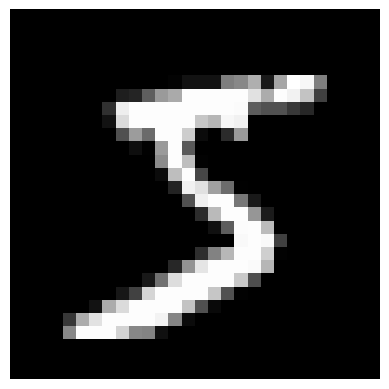

In [10]:
plt.imshow(first_image, cmap="gray")
plt.axis("off");

In [11]:
# small reusable IDX parser

def parse_idx_gz(content):
    data = gzip.decompress(content)

    # the first 4 bytes are the IDX "magic number", which identifies the type of data (2051 = images, 2049 = labels)
    magic = struct.unpack(">I", data[:4])[0]

    # MNIST image file
    if magic == 2051:  
        # image header contains: magic number, number of images, rows, columns
        _, n, rows, cols = struct.unpack(">IIII", data[:16])

        # remaining bytes contain one uint8 value per pixel
        images = np.frombuffer(
            data,
            dtype=np.uint8,
            offset=16
        ).reshape(n, rows, cols)

        return images

    # MNIST label file
    elif magic == 2049:  
        # label header contains: magic number, number of labels
        _, n = struct.unpack(">II", data[:8])

        # remaining bytes contain one uint8 label per image
        labels = np.frombuffer(
            data,
            dtype=np.uint8,
            offset=8
        )

        return labels

    else:
        raise ValueError(f"Unknown IDX magic number: {magic}")

### Extract the four MNIST files from Spark

In [12]:
# collect the four small MNIST files from Spark into Python

files = binary_df.collect()

# store each parsed dataset using its original filename as the key
mnist_data = {}

for row in files:
    # extract just the filename from the full HDFS path
    filename = row.path.split("/")[-1]

    # decompress and parse the IDX binary data
    mnist_data[filename] = parse_idx_gz(row.content)

# check that all four files were parsed with the expected shapes
for name, array in mnist_data.items():
    print(name, array.shape, array.dtype)

train-images-idx3-ubyte.gz (60000, 28, 28) uint8
t10k-images-idx3-ubyte.gz (10000, 28, 28) uint8
train-labels-idx1-ubyte.gz (60000,) uint8
t10k-labels-idx1-ubyte.gz (10000,) uint8


### Convert the MNIST data to PyTorch tensors

In [13]:
# convert training images from uint8 values 0-255 to float32 values 0-1
# unsqueeze adds the channel dimension required by the CNN: [N, 1, 28, 28]
X_train = torch.tensor(
    mnist_data["train-images-idx3-ubyte.gz"],
    dtype=torch.float32
).unsqueeze(1) / 255.0

# labels are class indices, so use long integers
y_train = torch.tensor(
    mnist_data["train-labels-idx1-ubyte.gz"],
    dtype=torch.long
)

# apply the same conversion to the test images
X_test = torch.tensor(
    mnist_data["t10k-images-idx3-ubyte.gz"],
    dtype=torch.float32
).unsqueeze(1) / 255.0

# convert test labels to long integers for the classification loss
y_test = torch.tensor(
    mnist_data["t10k-labels-idx1-ubyte.gz"],
    dtype=torch.long
)

# check that the tensors have the same structure as the tensors
# used in our original PyTorch MNIST experiment
print("Training:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)
print("Range:", X_train.min().item(), "to", X_train.max().item())

Training: torch.Size([60000, 1, 28, 28]) torch.Size([60000])
Test: torch.Size([10000, 1, 28, 28]) torch.Size([10000])
Range: 0.0 to 1.0


In [14]:
from torch.utils.data import TensorDataset, DataLoader

# wrap the tensors so that images and labels are returned together
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

# create mini-batches for CNN training and evaluation
# use the same batch size as in the baseline experiment
batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Test batches:", len(test_loader))

Training batches: 469
Test batches: 79


## Same CNN Architecture

In [16]:
import torch.nn as nn
import torch.nn.functional as F

class MNISTCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=16,
            kernel_size=3
        )

        self.conv2 = nn.Conv2d(
            in_channels=16,
            out_channels=32,
            kernel_size=3
        )

        self.pool = nn.MaxPool2d(kernel_size=2)

        self.fc1 = nn.Linear(32 * 5 * 5, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = torch.flatten(x, start_dim=1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [17]:
model = MNISTCNN()
print(model)

MNISTCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=800, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [19]:
images, labels = next(iter(train_loader))
outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)

Input shape: torch.Size([128, 1, 28, 28])
Output shape: torch.Size([128, 10])


In [20]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

learning_rate = 0.001

In [21]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # CrossEntropyLoss() by default returns the average loss for the batch
        # we want the running_loss to represent the sum of the individual sample losses
        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [22]:
def evaluate(model, loader, criterion):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    # we're telling PyTorch that this is evaluation rather than training, and that we don't need to calculate gradients
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [25]:
history = {
    "train_loss": [],
    "train_accuracy": [],
    "test_loss": [],
    "test_accuracy": [],
    "epoch_time": []
}

epochs = 5

for epoch in range(epochs):
    start_time = time.time()

    train_loss, train_accuracy = train_one_epoch(model, train_loader, criterion, optimizer)

    test_loss, test_accuracy = evaluate(model, test_loader, criterion)

    epoch_time = time.time() - start_time

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["test_loss"].append(test_loss)
    history["test_accuracy"].append(test_accuracy)
    history["epoch_time"].append(epoch_time)

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Train loss: {train_loss:.4f} | "
        f"Train acc: {train_accuracy:.4f} | "
        f"Test loss: {test_loss:.4f} | "
        f"Test acc: {test_accuracy:.4f} | "
        f"Time: {epoch_time:.2f}s"
    )

Epoch 1/5 | Train loss: 0.3543 | Train acc: 0.8963 | Test loss: 0.1089 | Test acc: 0.9656 | Time: 17.36s
Epoch 2/5 | Train loss: 0.0956 | Train acc: 0.9712 | Test loss: 0.0641 | Test acc: 0.9801 | Time: 15.23s
Epoch 3/5 | Train loss: 0.0652 | Train acc: 0.9802 | Test loss: 0.0462 | Test acc: 0.9853 | Time: 15.26s
Epoch 4/5 | Train loss: 0.0515 | Train acc: 0.9844 | Test loss: 0.0443 | Test acc: 0.9848 | Time: 15.66s
Epoch 5/5 | Train loss: 0.0416 | Train acc: 0.9872 | Test loss: 0.0358 | Test acc: 0.9887 | Time: 14.92s


In [26]:
# overall training time
total_training_time = sum(history["epoch_time"])

print(f"Total training time: {total_training_time:.2f} seconds")
print(f"Average epoch time: {np.mean(history['epoch_time']):.2f} seconds")
print(f"Final test accuracy: {history['test_accuracy'][-1]:.4f}")

Total training time: 78.42 seconds
Average epoch time: 15.68 seconds
Final test accuracy: 0.9887
